In [27]:
import os
import keras
from keras.applications import inception_v3 as inc_net
from keras.preprocessing import image
from keras.applications.imagenet_utils import decode_predictions
from skimage.io import imread
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd

In [28]:
inet_model=inc_net.InceptionV3()

In [29]:
def transform_img_def(path_list):
  out = []
  for img_path in path_list:
    img = image.load_img(img_path, target_size=(299,299))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = inc_net.preprocess_input(x)
    out.append(x)

  return np.vstack(out)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step
('n03933933', 'pier', np.float32(0.51251197))
('n04366367', 'suspension_bridge', np.float32(0.3137034))
('n09399592', 'promontory', np.float32(0.05510414))
('n03095699', 'container_ship', np.float32(0.014074308))
('n02730930', 'apron', np.float32(0.004080926))


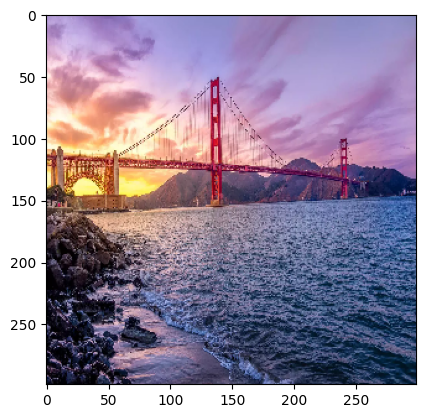

In [43]:
images = transform_img_def([os.path.join('data','golden_gate.webp')])

plt.imshow(images[0]/2 + 0.5)
pred = inet_model.predict(images)
for x in decode_predictions(pred)[0]:
  print(x)

In [31]:
!pip install lime

In [32]:
from lime import lime_image

In [33]:
explainer = lime_image.LimeImageExplainer()

In [44]:
explanation = explainer.explain_instance(images[0].astype('double'), inet_model.predict, top_labels=5, hide_color=0, num_samples=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

In [45]:
from skimage.segmentation import mark_boundaries

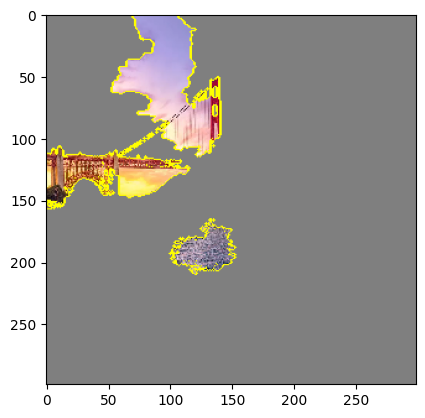

In [46]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=4, hide_rest=True)
plt.imshow(mark_boundaries(temp/2 + 0.5, mask))

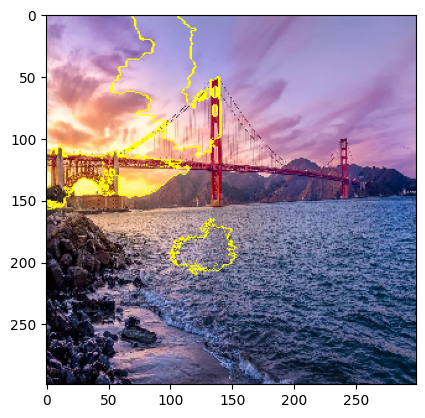

In [47]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=4, hide_rest=False)
plt.imshow(mark_boundaries(temp/2 + 0.5, mask))

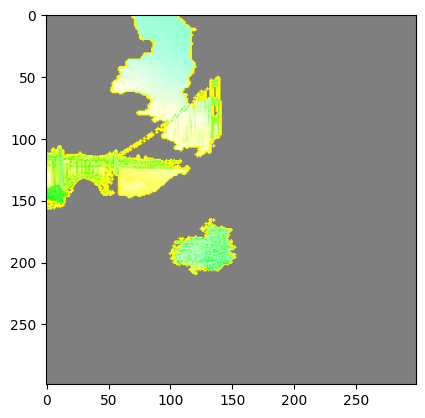

In [48]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=4, hide_rest=True)
plt.imshow(mark_boundaries(temp/2 + 0.5, mask))

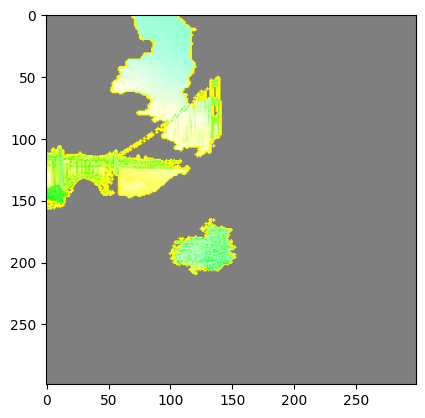

In [49]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=4, hide_rest=True, min_weight=0.01 )
plt.imshow(mark_boundaries(temp/2 + 0.5, mask))

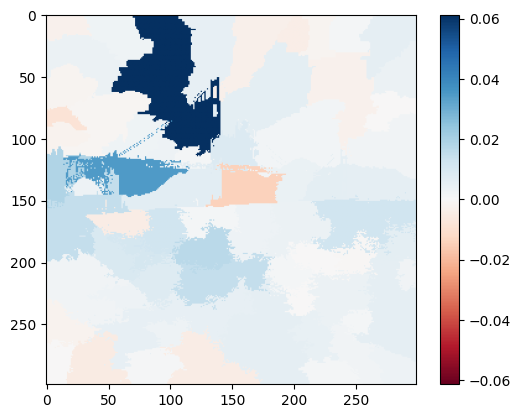

In [50]:
ind = explanation.top_labels[0]

dict_heatmap = dict(explanation.local_exp[ind])
heatmap = np.vectorize(dict_heatmap.get)(explanation.segments)

plt.imshow(heatmap, cmap='RdBu', vmin=-heatmap.max(), vmax=heatmap.max())
plt.colorbar()

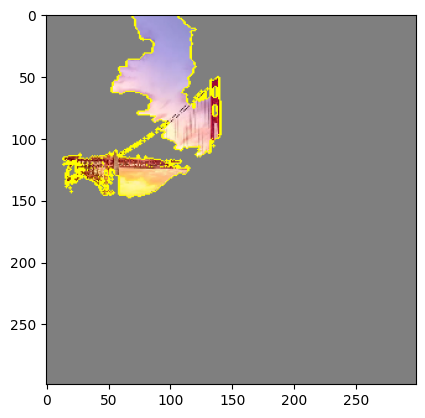

In [51]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[1], positive_only=True, num_features=2, hide_rest=True)
plt.imshow(mark_boundaries(temp/2 + 0.5, mask))

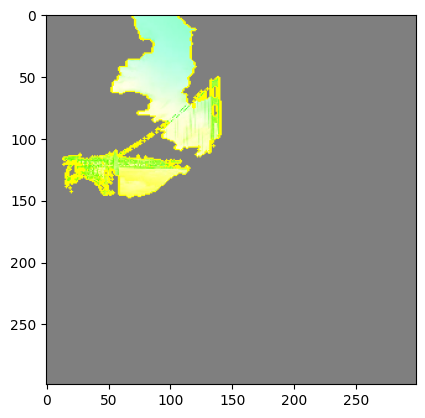

In [52]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[1], positive_only=False, num_features=2, hide_rest=True)
plt.imshow(mark_boundaries(temp/2 + 0.5, mask))